In [58]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, cohen_kappa_score, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn as sns
import re

In [2]:
emotions_col = ['Wonder', 'Transcendence', 'Nostalgia',
                'Tenderness', 'Peacefulness', 'Joy',
                'Sadness', 'Power','Tension']

In [ ]:
# Parse the textfiles of the results into Dataframes
def decode_results(results_file, emotions_col = emotions_col):

    rows = []
 
    with open(results_file, "r") as f:
        
        for line in f:
            line = line.strip()
            
            row = {}
            for emotion in emotions_col:
                pattern = rf"-\s*{emotion}:\s*(\d+)"
                match = re.search(pattern, line)
                row[emotion] = int(match.group(1)) if match else None
    
            rows.append(row)

    df = pd.DataFrame(rows, columns=emotions_col)
    df.index += 1
    
    return df

### Load results and compute metrics 

In [3]:
# Import the Datasets
test_recoded_df = pd.read_csv('../data/test.csv')
test_og_df = pd.read_csv('../data/test_og.csv')

# Music Flamingo :
# Base model predictions
MF_base_df = pd.read_csv('../results/MF_test_results.csv',
                         na_values='None')
MF_base_single = pd.read_csv('../results/MF_single_emo.csv',
                         na_values='None')
MF_base_random = pd.read_csv('../results/MF_randomized_results.csv',
                         na_values='None')
MF_base_og = pd.read_csv('../results/MF_og_test.csv',
                         na_values='None')

# Finetuned model predictions
MF_finetuned_df = pd.read_csv('../results/MF_finetuned_results.csv',
                      na_values='None')

# Voxtral :
# Base model predictions
Voxtral_base_df = pd.read_csv('../results/Voxtral_test_results.csv',
                      na_values='None')
Voxtral_base_single = pd.read_csv('../results/Voxtral_single_emo.csv',
                      na_values='None')
Voxtral_base_random = pd.read_csv('../results/Voxtral_randomized_results.csv',
                      na_values='None')
Voxtral_base_og = pd.read_csv('../results/Voxtral_og_test.csv',
                      na_values='None')

# Finetuned model predictions
Voxtral_finetuned_df = pd.read_csv('../results/Voxtral_finetuned_results.csv',
                      na_values='None')

In [ ]:
def compute_metrics(model_pred, test_data = test_recoded_df, og_data = False):
    """
    Compute different errors for the results

    Args:
        model_pred : Dataframe of the predictions
        test_data : Dataframe of the true values
        og_data (bool) : True if the data was computed for the original (0-100) scores
    """

    # Define lists for each error type
    emo_mae = []
    emo_rmse = []
    emo_kappa = []
    emo_nmae = [] 
    missing_values = []

    # Metric computation for each emotion
    for emo in emotions_col:

        # Mask the missing values
        mask = model_pred[emo].notna()
        actual = test_data.loc[mask, emo]
        predicted = model_pred.loc[mask, emo]

        # Compute Mean Absolute error
        mae = mean_absolute_error(actual, predicted)
        emo_mae.append(round(mae, 3))

        # Compute Mean Absolute Error, normalized on the max error
        nmae = mae/4 if og_data == False else mae/100
        emo_nmae.append(round(nmae,3))

        # Compute Root Mean Squarred error
        nrmse = root_mean_squared_error(actual,predicted)
        nrmse = nrmse/4 if og_data == False else nrmse/100
        emo_rmse.append(round(nrmse, 3))

        # Compute Cohen Kappa
        if og_data == False:
            kappa = cohen_kappa_score(actual,predicted, weights='quadratic')
            emo_kappa.append(round(kappa, 3))
        
        # Count the missing values
        missing_values.append(int(model_pred[emo].isna().sum()))

    # Save the metrics in dict
    emo_metrics = {'mae': emo_mae,
                   'nmae': emo_nmae,
                   'nrmse': emo_rmse,
                   'kappa': emo_kappa if len(emo_kappa) > 0 else None,
                   'missing values': missing_values}
    
    # Filter and drop the missing values
    mask = model_pred[emotions_col].notna()
    actual = test_data[emotions_col].where(mask).dropna()
    predicted = model_pred[emotions_col].where(mask).dropna()

    # Ravel all the data
    actual = actual.values.ravel()
    predicted = predicted.values.ravel()

    # Global Metrics
    # Compute global MAE
    glob_mae = mean_absolute_error(actual, predicted)
    # Compute global NMAE
    glob_nmae = glob_mae/4 if og_data == False else glob_mae/100
    # Compute global NRMSE
    glob_nrmse = root_mean_squared_error(actual,predicted)/4 if og_data == False else root_mean_squared_error(actual,predicted)/100
    # Compute global Kappa
    glob_kappa = round(cohen_kappa_score(actual,predicted, weights='quadratic'),3) if og_data == False else None #round(np.mean(emo_kappa),3)

    glob_metrics = {'mae': round(glob_mae,3),
                    'nmae': round(glob_nmae,3),
                    'nrmse': round(glob_nrmse,3),
                    'kappa': glob_kappa,
                    }

    return  emo_metrics, glob_metrics

### Music flamingo Metrics

In [5]:
mf_base_metrics = compute_metrics(MF_base_df)
mf_base_metrics

({'mae': [0.965, 0.991, 1.583, 0.957, 1.061, 1.574, 0.757, 1.009, 0.92],
  'nmae': [0.241, 0.248, 0.396, 0.239, 0.265, 0.393, 0.189, 0.252, 0.23],
  'nrmse': [0.31, 0.33, 0.49, 0.335, 0.326, 0.485, 0.301, 0.33, 0.333],
  'kappa': [0.095, 0.245, 0.108, 0.476, 0.472, 0.314, 0.278, 0.454, 0.324],
  'missing values': [0, 0, 0, 0, 0, 0, 0, 0, 2]},
 {'mae': 1.088, 'nmae': 0.272, 'nrmse': 0.367, 'kappa': 0.367})

In [6]:
mf_og_metrics = compute_metrics(MF_base_og, test_og_df, og_data=True)
mf_og_metrics

({'mae': [48.881,
   51.192,
   30.611,
   32.485,
   26.989,
   21.146,
   18.206,
   26.911,
   21.05],
  'nmae': [0.489, 0.512, 0.306, 0.325, 0.27, 0.211, 0.182, 0.269, 0.21],
  'nrmse': [0.513, 0.539, 0.34, 0.366, 0.328, 0.259, 0.251, 0.326, 0.268],
  'kappa': None,
  'missing values': [0, 0, 0, 0, 0, 0, 0, 0, 1]},
 {'mae': 30.959, 'nmae': 0.31, 'nrmse': 0.369, 'kappa': None})

In [7]:
mf_random_metrics = compute_metrics(MF_base_random)
mf_random_metrics

({'mae': [0.887, 0.939, 1.33, 1.018, 1.287, 1.53, 0.93, 1.026, 0.922],
  'nmae': [0.222, 0.235, 0.333, 0.254, 0.322, 0.383, 0.233, 0.257, 0.23],
  'nrmse': [0.293, 0.32, 0.428, 0.355, 0.412, 0.466, 0.326, 0.333, 0.32],
  'kappa': [0.271, 0.119, 0.195, 0.285, 0.266, 0.322, 0.19, 0.486, 0.382],
  'missing values': [0, 0, 0, 1, 0, 0, 0, 0, 0]},
 {'mae': 1.096, 'nmae': 0.274, 'nrmse': 0.366, 'kappa': 0.328})

In [8]:
mf_single_emo_metrics = compute_metrics(MF_base_single)
mf_single_emo_metrics

({'mae': [0.861, 0.887, 1.139, 0.93, 0.93, 0.991, 1.2, 0.948, 1.104],
  'nmae': [0.215, 0.222, 0.285, 0.233, 0.233, 0.248, 0.3, 0.237, 0.276],
  'nrmse': [0.285, 0.286, 0.334, 0.298, 0.305, 0.304, 0.352, 0.294, 0.329],
  'kappa': [0.187, 0.169, 0.175, 0.467, 0.523, 0.449, 0.161, 0.407, 0.183],
  'missing values': [0, 0, 0, 0, 0, 0, 0, 0, 0]},
 {'mae': 0.999, 'nmae': 0.25, 'nrmse': 0.31, 'kappa': 0.359})

In [9]:
mf_finetuned_metrics = compute_metrics(MF_finetuned_df)
mf_finetuned_metrics

({'mae': [1.096, 0.73, 1.565, 1.113, 1.383, 1.026, 0.87, 0.991, 1.0],
  'nmae': [0.274, 0.183, 0.391, 0.278, 0.346, 0.257, 0.217, 0.248, 0.25],
  'nrmse': [0.361, 0.268, 0.485, 0.372, 0.439, 0.354, 0.344, 0.323, 0.327],
  'kappa': [0.0, 0.0, 0.0, 0.012, 0.011, 0.237, 0.005, 0.455, 0.24],
  'missing values': [0, 0, 0, 0, 0, 0, 0, 0, 0]},
 {'mae': 1.086, 'nmae': 0.271, 'nrmse': 0.369, 'kappa': 0.315})

### Voxtral predictions metrics

In [10]:
voxtral_base_metrics = compute_metrics(Voxtral_base_df)
voxtral_base_metrics

({'mae': [1.026, 0.922, 1.191, 1.139, 1.148, 2.165, 1.252, 1.722, 1.062],
  'nmae': [0.257, 0.23, 0.298, 0.285, 0.287, 0.541, 0.313, 0.43, 0.265],
  'nrmse': [0.325, 0.291, 0.366, 0.359, 0.4, 0.629, 0.412, 0.542, 0.366],
  'kappa': [0.16, 0.203, 0.143, 0.234, 0.303, 0.097, 0.223, 0.114, 0.273],
  'missing values': [0, 0, 0, 0, 0, 0, 0, 0, 2]},
 {'mae': 1.295, 'nmae': 0.324, 'nrmse': 0.424, 'kappa': 0.17})

In [11]:
voxtral_og_metrics = compute_metrics(Voxtral_base_og, test_og_df, og_data=True)
voxtral_og_metrics

({'mae': [58.186,
   49.087,
   30.13,
   32.375,
   28.549,
   15.451,
   24.622,
   19.645,
   18.59],
  'nmae': [0.582, 0.491, 0.301, 0.324, 0.285, 0.155, 0.246, 0.196, 0.186],
  'nrmse': [0.597, 0.505, 0.332, 0.355, 0.347, 0.193, 0.317, 0.254, 0.246],
  'kappa': None,
  'missing values': [0, 0, 0, 0, 0, 0, 0, 0, 0]},
 {'mae': 30.737, 'nmae': 0.307, 'nrmse': 0.37, 'kappa': None})

In [12]:
voxtral_random_metrics = compute_metrics(Voxtral_base_random)
voxtral_random_metrics

({'mae': [0.868, 0.904, 1.33, 1.261, 1.391, 1.496, 1.096, 1.212, 1.061],
  'nmae': [0.217, 0.226, 0.333, 0.315, 0.348, 0.374, 0.274, 0.303, 0.265],
  'nrmse': [0.301, 0.299, 0.41, 0.384, 0.439, 0.464, 0.354, 0.39, 0.352],
  'kappa': [0.215, 0.24, 0.062, 0.157, 0.101, 0.156, 0.202, 0.136, 0.139],
  'missing values': [1, 0, 0, 0, 0, 0, 0, 2, 0]},
 {'mae': 1.183, 'nmae': 0.296, 'nrmse': 0.38, 'kappa': 0.178})

In [13]:
voxtral_single_emo_metrics = compute_metrics(Voxtral_base_single)
voxtral_single_emo_metrics

({'mae': [1.217, 1.504, 1.209, 1.661, 1.174, 1.287, 2.078, 1.298, 1.8],
  'nmae': [0.304, 0.376, 0.302, 0.415, 0.293, 0.322, 0.52, 0.325, 0.45],
  'nrmse': [0.376, 0.428, 0.377, 0.476, 0.377, 0.374, 0.571, 0.389, 0.514],
  'kappa': [-0.021, 0.044, -0.017, 0.087, 0.189, -0.095, 0.031, 0.046, 0.021],
  'missing values': [0, 0, 0, 0, 0, 0, 0, 1, 0]},
 {'mae': 1.464, 'nmae': 0.366, 'nrmse': 0.435, 'kappa': 0.01})

In [14]:
voxtral_finetuned_metrics = compute_metrics(Voxtral_finetuned_df)
voxtral_finetuned_metrics

({'mae': [1.035, 0.757, 0.991, 1.017, 0.878, 0.791, 0.652, 1.0, 0.852],
  'nmae': [0.259, 0.189, 0.248, 0.254, 0.22, 0.198, 0.163, 0.25, 0.213],
  'nrmse': [0.334, 0.265, 0.358, 0.377, 0.322, 0.305, 0.275, 0.335, 0.32],
  'kappa': [0.24, 0.319, 0.528, 0.562, 0.595, 0.607, 0.588, 0.577, 0.519],
  'missing values': [0, 0, 0, 0, 0, 0, 0, 0, 0]},
 {'mae': 0.886, 'nmae': 0.221, 'nrmse': 0.323, 'kappa': 0.602})

### Radar Charts

In [15]:
def emo_radar_charts(errors_list, legends_list = [] ,title = 'Radar Chart', min_tick = 0, max_tick = 4):
  
    # Set the labels name
    emo_abrv = {'Wonder': 'WDR', 'Transcendence' : 'TSD', 'Nostalgia': 'NTG',
                'Tenderness': 'TDN', 'Peacefulness': 'PFN', 'Joy': 'JOY',
                'Power': 'PWR','Tension': 'TSN','Sadness': 'SDN'}
    labels = [emo_abrv[emo] for emo in emotions_col]
        
    # Number of variables
    num_vars = len(labels)

    # Compute angle of each axis in the plot (in radians)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]
    
    # Colormap
    colors_magma = plt.cm.magma(np.linspace(.1, .9, len(errors_list)))
    
    # Create the figure
    fig, ax = plt.subplots(figsize=(5, 5),subplot_kw=dict(polar=True))

    if len(legends_list) != 0 and len(errors_list) != len(legends_list):
        print('errors_list and legends_list must have the same lenght')

    for i,e_list in enumerate(errors_list) :
        
        # Values
        errors = [e if e > 0 else 0 for e in e_list.copy()]
        errors += errors[:1]
        print(errors)

        # Draw the outline of the radar chart
        ax.plot(angles, errors, color=colors_magma[i], linewidth=1.5, linestyle='solid', 
                label = legends_list[i] if len(legends_list)>0 else None)
        ax.fill(angles, errors, color=colors_magma[i], alpha=0.3)
        
    # Set the labels for each axis with matching rotation
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([])

    for angle, label in zip(angles[:-1], labels):
        
        angle_deg = np.degrees(angle)

        # Adjust rotation so text aligns with its axis.
        if 90 < angle_deg < 270:
            rotation = angle_deg + 180
        else:
            rotation = angle_deg

        ax.text(
            angle, max_tick * 1.1,
            label,
            ha='center', va='center',
            rotation=rotation,
            rotation_mode='anchor',
            size=10, color='#222222')

    # Set the range for radial axis
    # ax.set_ylim(min_tick, max_tick)
    ax.set_yticks(np.linspace(min_tick,max_tick, 5))

    # Customisation
    ax.tick_params(colors='#222222')
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(color='#AAAAAA')
    ax.spines['polar'].set_color('#222222')
    ax.set_facecolor('#FAFAFA')

    # Add a title
    ax.set_title(title, size=12, y=1.08)

    # Add a legend.
    if len(legends_list) > 0:
        ax.legend(loc='upper right', bbox_to_anchor=(1.5, 1.15))

    # Show the plot
    plt.show()

    return fig, ax

#### Music Flamingo Charts

[0.965, 0.991, 1.583, 0.957, 1.061, 1.574, 0.757, 1.009, 0.92, 0.965]
[1.096, 0.73, 1.565, 1.113, 1.383, 1.026, 0.87, 0.991, 1.0, 1.096]
[0.861, 0.887, 1.139, 0.93, 0.93, 0.991, 1.2, 0.948, 1.104, 0.861]
[0.887, 0.939, 1.33, 1.018, 1.287, 1.53, 0.93, 1.026, 0.922, 0.887]


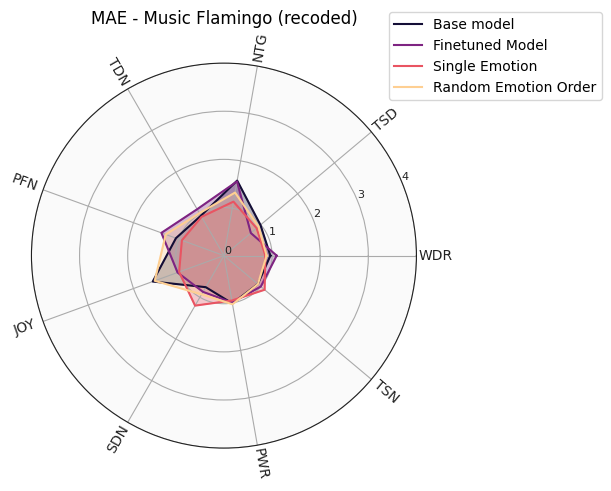

(<Figure size 500x500 with 1 Axes>,
 <PolarAxes: title={'center': 'MAE - Music Flamingo (recoded)'}>)

In [16]:
mf_metrics = [mf_base_metrics[0]['mae'], mf_finetuned_metrics[0]['mae'], mf_single_emo_metrics[0]['mae'], mf_random_metrics[0]['mae']]
mf_legends = ['Base model', 'Finetuned Model', 'Single Emotion', 'Random Emotion Order']
emo_radar_charts(mf_metrics, mf_legends, title = 'MAE - Music Flamingo (recoded)', max_tick=4)

[0.095, 0.245, 0.108, 0.476, 0.472, 0.314, 0.278, 0.454, 0.324, 0.095]
[0, 0, 0, 0.012, 0.011, 0.237, 0.005, 0.455, 0.24, 0]
[0.187, 0.169, 0.175, 0.467, 0.523, 0.449, 0.161, 0.407, 0.183, 0.187]
[0.271, 0.119, 0.195, 0.285, 0.266, 0.322, 0.19, 0.486, 0.382, 0.271]


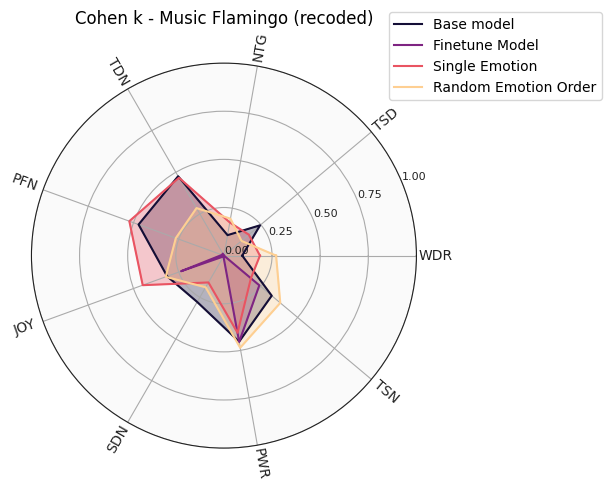

(<Figure size 500x500 with 1 Axes>,
 <PolarAxes: title={'center': 'Cohen k - Music Flamingo (recoded)'}>)

In [17]:
mf_metrics = [mf_base_metrics[0]['kappa'], mf_finetuned_metrics[0]['kappa'], mf_single_emo_metrics[0]['kappa'], mf_random_metrics[0]['kappa']]
mf_legends = ['Base model', 'Finetune Model', 'Single Emotion', 'Random Emotion Order']
emo_radar_charts(mf_metrics, mf_legends, title = 'Cohen k - Music Flamingo (recoded)', max_tick=1)

[48.881, 51.192, 30.611, 32.485, 26.989, 21.146, 18.206, 26.911, 21.05, 48.881]


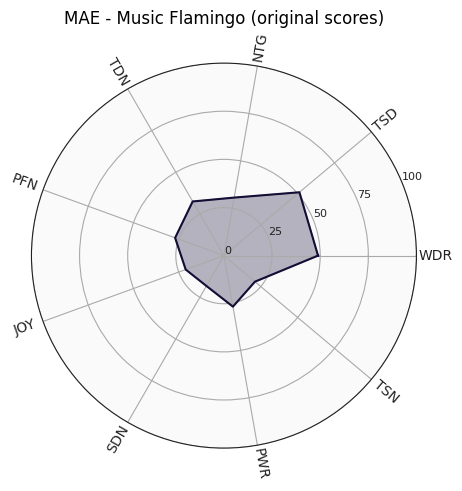

(<Figure size 500x500 with 1 Axes>,
 <PolarAxes: title={'center': 'MAE - Music Flamingo (original scores)'}>)

In [18]:
emo_radar_charts([mf_og_metrics[0]['mae']], title = 'MAE - Music Flamingo (original scores)', max_tick=100)

[0.241, 0.248, 0.396, 0.239, 0.265, 0.393, 0.189, 0.252, 0.23, 0.241]
[0.489, 0.512, 0.306, 0.325, 0.27, 0.211, 0.182, 0.269, 0.21, 0.489]


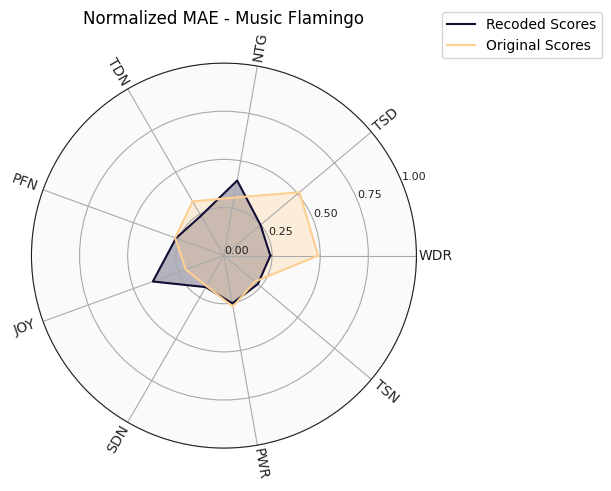

(<Figure size 500x500 with 1 Axes>,
 <PolarAxes: title={'center': 'Normalized MAE - Music Flamingo'}>)

In [19]:
mf_metrics = [mf_base_metrics[0]['nmae'], mf_og_metrics[0]['nmae']]
mf_legends = ['Recoded Scores', 'Original Scores']
emo_radar_charts(mf_metrics, mf_legends, title = 'Normalized MAE - Music Flamingo', max_tick=1)

#### Voxtral Charts

[1.026, 0.922, 1.191, 1.139, 1.148, 2.165, 1.252, 1.722, 1.062, 1.026]
[1.035, 0.757, 0.991, 1.017, 0.878, 0.791, 0.652, 1.0, 0.852, 1.035]
[1.217, 1.504, 1.209, 1.661, 1.174, 1.287, 2.078, 1.298, 1.8, 1.217]
[0.868, 0.904, 1.33, 1.261, 1.391, 1.496, 1.096, 1.212, 1.061, 0.868]


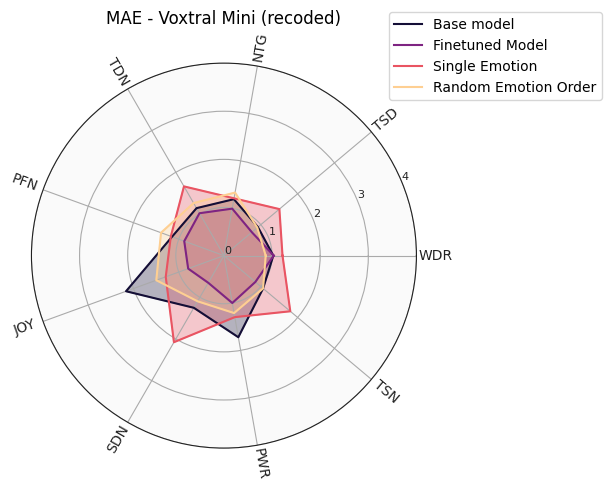

(<Figure size 500x500 with 1 Axes>,
 <PolarAxes: title={'center': 'MAE - Voxtral Mini (recoded)'}>)

In [20]:
voxtral_metrics = [voxtral_base_metrics[0]['mae'], voxtral_finetuned_metrics[0]['mae'], voxtral_single_emo_metrics[0]['mae'], voxtral_random_metrics[0]['mae']]
voxtral_legends = ['Base model', 'Finetuned Model', 'Single Emotion', 'Random Emotion Order']
emo_radar_charts(voxtral_metrics, voxtral_legends, title = 'MAE - Voxtral Mini (recoded)', max_tick=4)

[0.16, 0.203, 0.143, 0.234, 0.303, 0.097, 0.223, 0.114, 0.273, 0.16]
[0.24, 0.319, 0.528, 0.562, 0.595, 0.607, 0.588, 0.577, 0.519, 0.24]
[0, 0.044, 0, 0.087, 0.189, 0, 0.031, 0.046, 0.021, 0]
[0.215, 0.24, 0.062, 0.157, 0.101, 0.156, 0.202, 0.136, 0.139, 0.215]


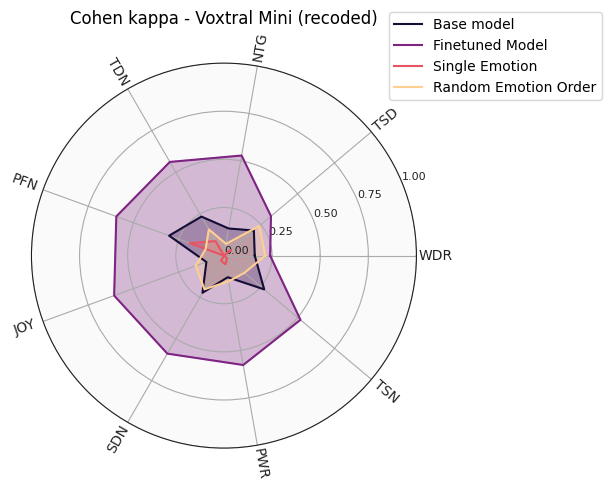

(<Figure size 500x500 with 1 Axes>,
 <PolarAxes: title={'center': 'Cohen kappa - Voxtral Mini (recoded)'}>)

In [21]:
voxtral_metrics = [voxtral_base_metrics[0]['kappa'], voxtral_finetuned_metrics[0]['kappa'], voxtral_single_emo_metrics[0]['kappa'], voxtral_random_metrics[0]['kappa']]
voxtral_legends = ['Base model', 'Finetuned Model', 'Single Emotion', 'Random Emotion Order']
emo_radar_charts(voxtral_metrics, voxtral_legends, title = 'Cohen kappa - Voxtral Mini (recoded)', max_tick=1)

[58.186, 49.087, 30.13, 32.375, 28.549, 15.451, 24.622, 19.645, 18.59, 58.186]


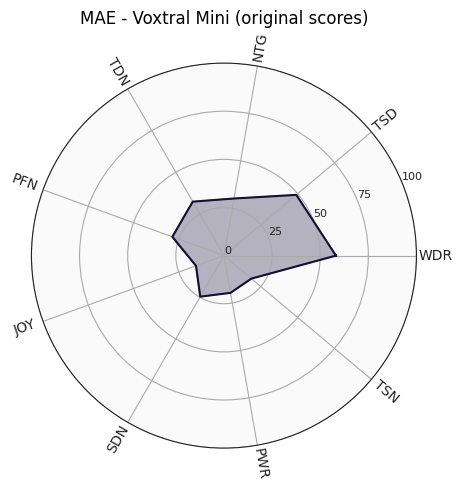

(<Figure size 500x500 with 1 Axes>,
 <PolarAxes: title={'center': 'MAE - Voxtral Mini (original scores)'}>)

In [22]:
emo_radar_charts([voxtral_og_metrics[0]['mae']], title = 'MAE - Voxtral Mini (original scores)', max_tick=100)

[0.257, 0.23, 0.298, 0.285, 0.287, 0.541, 0.313, 0.43, 0.265, 0.257]
[0.582, 0.491, 0.301, 0.324, 0.285, 0.155, 0.246, 0.196, 0.186, 0.582]


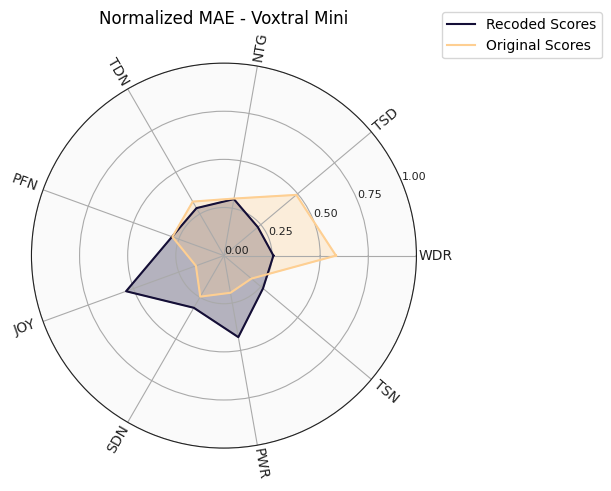

(<Figure size 500x500 with 1 Axes>,
 <PolarAxes: title={'center': 'Normalized MAE - Voxtral Mini'}>)

In [23]:
mf_metrics = [voxtral_base_metrics[0]['nmae'], voxtral_og_metrics[0]['nmae']]
mf_legends = ['Recoded Scores', 'Original Scores']
emo_radar_charts(mf_metrics, mf_legends, title = 'Normalized MAE - Voxtral Mini', max_tick=1)

#### Music Flamingo v. Voxtral Charts

[0.965, 0.991, 1.583, 0.957, 1.061, 1.574, 0.757, 1.009, 0.92, 0.965]
[1.096, 0.73, 1.565, 1.113, 1.383, 1.026, 0.87, 0.991, 1.0, 1.096]
[1.026, 0.922, 1.191, 1.139, 1.148, 2.165, 1.252, 1.722, 1.062, 1.026]
[1.035, 0.757, 0.991, 1.017, 0.878, 0.791, 0.652, 1.0, 0.852, 1.035]


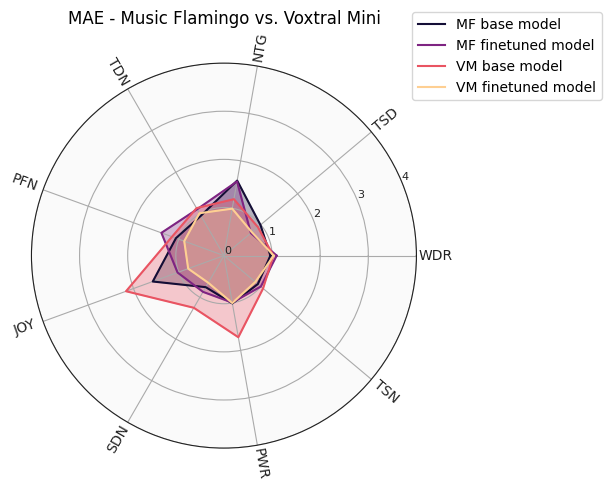

(<Figure size 500x500 with 1 Axes>,
 <PolarAxes: title={'center': 'MAE - Music Flamingo vs. Voxtral Mini'}>)

In [24]:
metrics = [mf_base_metrics[0]['mae'],  mf_finetuned_metrics[0]['mae'], voxtral_base_metrics[0]['mae'],voxtral_finetuned_metrics[0]['mae']]
legends = ['MF base model', 'MF finetuned model','VM base model',  'VM finetuned model']
emo_radar_charts(metrics, legends, title='MAE - Music Flamingo vs. Voxtral Mini')

[0.095, 0.245, 0.108, 0.476, 0.472, 0.314, 0.278, 0.454, 0.324, 0.095]
[0, 0, 0, 0.012, 0.011, 0.237, 0.005, 0.455, 0.24, 0]
[0.16, 0.203, 0.143, 0.234, 0.303, 0.097, 0.223, 0.114, 0.273, 0.16]
[0.24, 0.319, 0.528, 0.562, 0.595, 0.607, 0.588, 0.577, 0.519, 0.24]


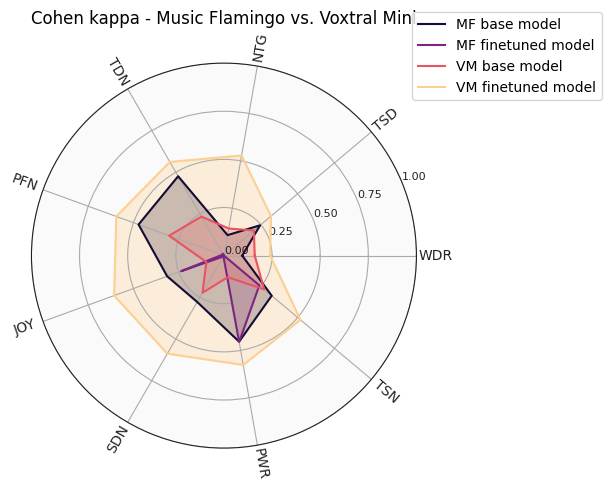

(<Figure size 500x500 with 1 Axes>,
 <PolarAxes: title={'center': 'Cohen kappa - Music Flamingo vs. Voxtral Mini'}>)

In [25]:
metrics = [mf_base_metrics[0]['kappa'],  mf_finetuned_metrics[0]['kappa'], voxtral_base_metrics[0]['kappa'],voxtral_finetuned_metrics[0]['kappa']]
legends = ['MF base model', 'MF finetuned model','VM base model',  'VM finetuned model']
emo_radar_charts(metrics, legends, title='Cohen kappa - Music Flamingo vs. Voxtral Mini', max_tick=1)

[0.241, 0.248, 0.396, 0.239, 0.265, 0.393, 0.189, 0.252, 0.23, 0.241]
[0.274, 0.183, 0.391, 0.278, 0.346, 0.257, 0.217, 0.248, 0.25, 0.274]
[0.489, 0.512, 0.306, 0.325, 0.27, 0.211, 0.182, 0.269, 0.21, 0.489]
[0.257, 0.23, 0.298, 0.285, 0.287, 0.541, 0.313, 0.43, 0.265, 0.257]
[0.259, 0.189, 0.248, 0.254, 0.22, 0.198, 0.163, 0.25, 0.213, 0.259]
[0.582, 0.491, 0.301, 0.324, 0.285, 0.155, 0.246, 0.196, 0.186, 0.582]


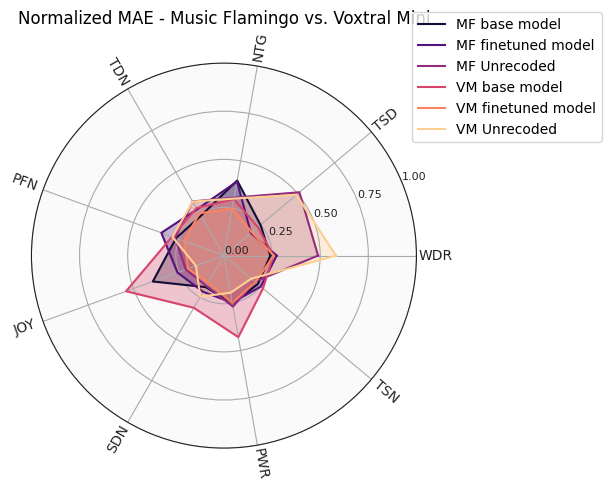

(<Figure size 500x500 with 1 Axes>,
 <PolarAxes: title={'center': 'Normalized MAE - Music Flamingo vs. Voxtral Mini'}>)

In [26]:
metrics = [mf_base_metrics[0]['nmae'],  mf_finetuned_metrics[0]['nmae'], mf_og_metrics[0]['nmae'],voxtral_base_metrics[0]['nmae'],voxtral_finetuned_metrics[0]['nmae'], voxtral_og_metrics[0]['nmae']]
legends = ['MF base model', 'MF finetuned model', 'MF Unrecoded','VM base model', 'VM finetuned model', 'VM Unrecoded']
emo_radar_charts(metrics, legends, title='Normalized MAE - Music Flamingo vs. Voxtral Mini', max_tick=1)

### Bar Charts

In [ ]:
def emo_bar_chart(error,errors_list, legends_list,title = 'Radar Chart', min_tick = 0, max_tick = 4):

    fig, ax = plt.subplots(figsize=(9, 6))

    # X positions for each emotion category
    x = np.arange(len(emotions_col))

    # Width of each bar (depends on number of groups)
    width = (1/len(errors_list))*.8
    mult = 0
    
    colors_magma = plt.cm.magma(np.linspace(.1, .9, len(errors_list)))

    # Loop through each set of errors
    for i,e_list in enumerate(errors_list) :

         # Shift bars for grouped display
        offset = width * mult

        # Plot bars for current error metric
        ax.bar(x + offset,
               e_list[0][error],
               width=width,
               color=colors_magma[i],
               label = legends_list[i])
        
        # Add horizontal line for global value
        ax.axhline(y=e_list[1][error],
            color=colors_magma[i],
            linewidth=1.5,
            linestyle='--',
            label= f'{'Global'} {error} ({e_list[1][error]:.3})')

        mult += 1
            
    ax.set_ylabel(error)
    ax.set_title(title)

    plt.xticks(ticks=x, labels=emotions_col, rotation=45, ha='right')

    # Rearange labels (global labels in second position)
    handles, labels = ax.get_legend_handles_labels()
    mid = int(len(handles)/2)
    handles = handles[mid:] + handles[:mid]
    labels = labels[mid:] + labels[:mid]
    ax.legend(handles=handles,labels=labels)
    ax.set_ylim(min_tick, max_tick)
    ax.grid(which='both',axis='y', linestyle='-', alpha=.5)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

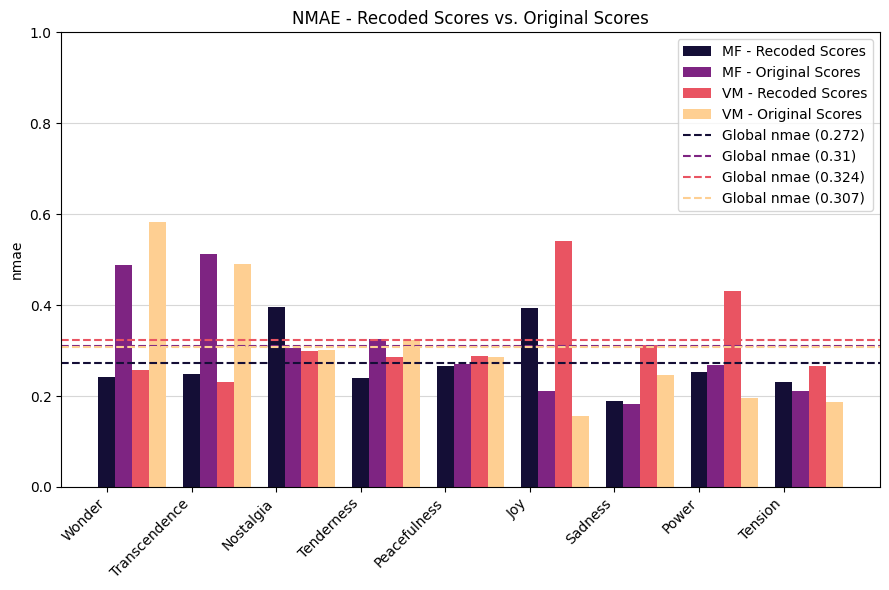

In [28]:
metrics = [mf_base_metrics,  mf_og_metrics, voxtral_base_metrics, voxtral_og_metrics]
legends = ['MF - Recoded Scores', 'MF - Original Scores','VM - Recoded Scores',  'VM - Original Scores']
emo_bar_chart('nmae', metrics, legends, title='NMAE - Recoded Scores vs. Original Scores', max_tick=1)

In [29]:
import math
for m in metrics:
    s = np.var(m[0]['nmae'])
    mu = np.mean(m[0]['nmae'])
    print(round(math.sqrt(s), 3), round(mu,3))
    

0.068 0.273
0.112 0.308
0.094 0.323
0.135 0.307


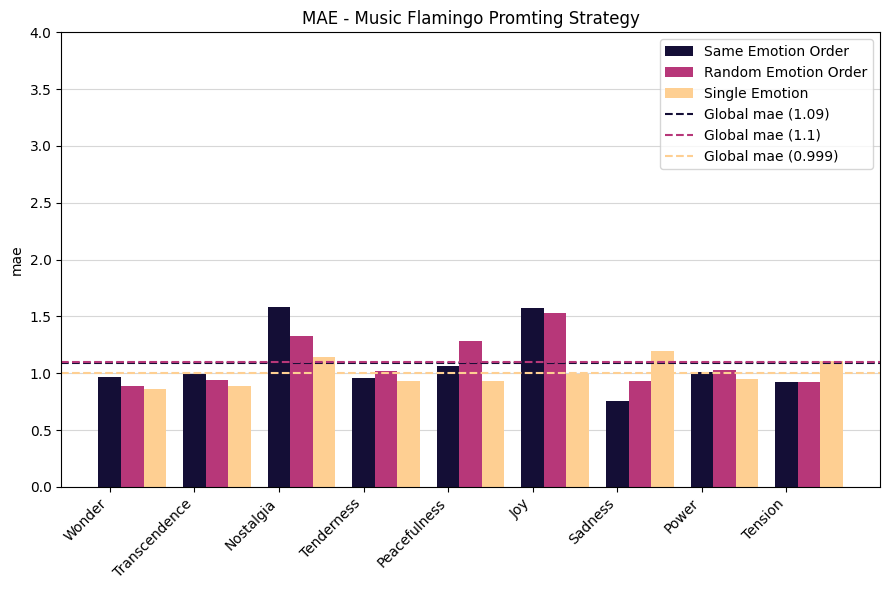

In [49]:
mf_metrics = [mf_base_metrics, mf_random_metrics, mf_single_emo_metrics]
mf_legends = ['Same Emotion Order', 'Random Emotion Order', 'Single Emotion']
emo_bar_chart('mae',mf_metrics, mf_legends, title = 'MAE - Music Flamingo Promting Strategy', max_tick=4)

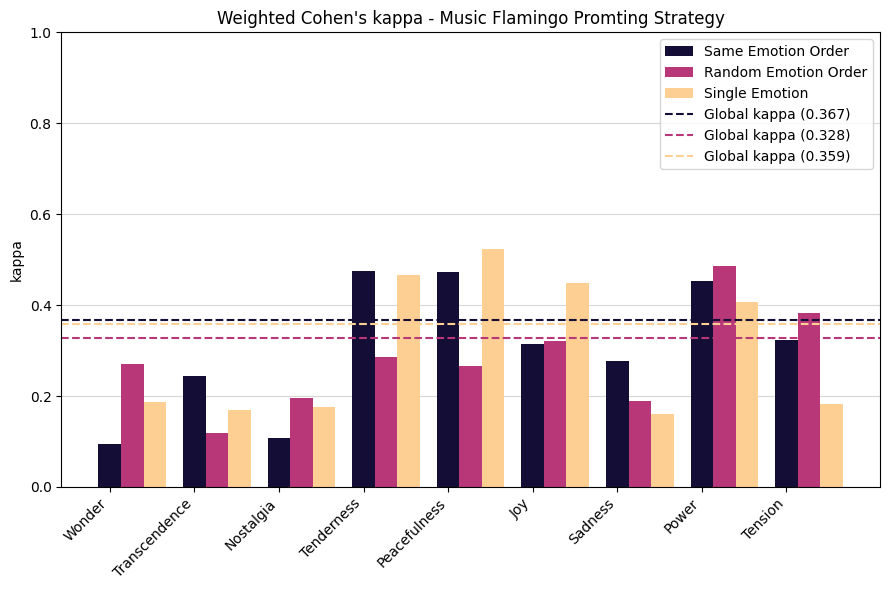

In [48]:
mf_metrics = [mf_base_metrics, mf_random_metrics, mf_single_emo_metrics]
mf_legends = ['Same Emotion Order', 'Random Emotion Order', 'Single Emotion']
emo_bar_chart('kappa',mf_metrics, mf_legends, title = 'Weighted Cohen\'s kappa - Music Flamingo Promting Strategy', max_tick=1)

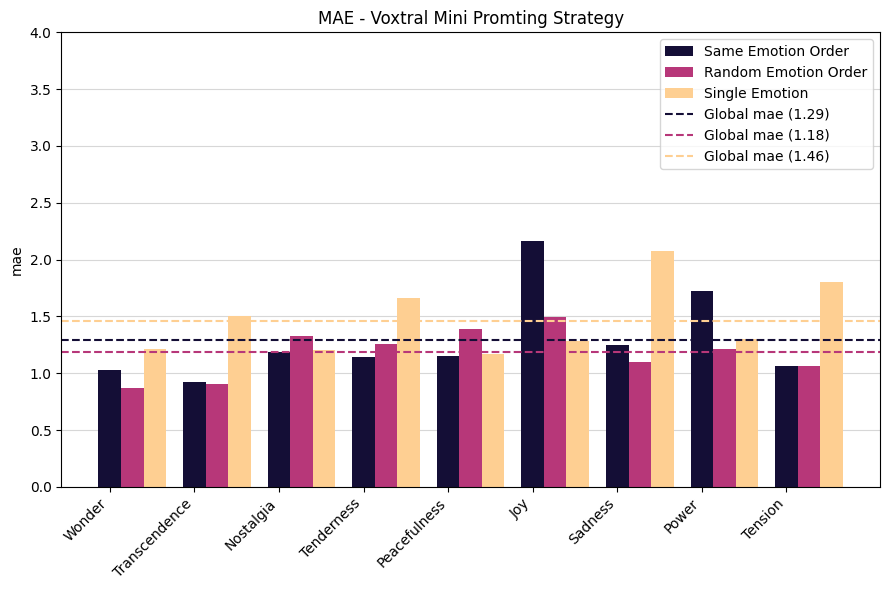

In [50]:
mf_metrics = [voxtral_base_metrics, voxtral_random_metrics, voxtral_single_emo_metrics]
mf_legends = ['Same Emotion Order', 'Random Emotion Order', 'Single Emotion']
emo_bar_chart('mae',mf_metrics, mf_legends, title = 'MAE - Voxtral Mini Promting Strategy', max_tick=4)

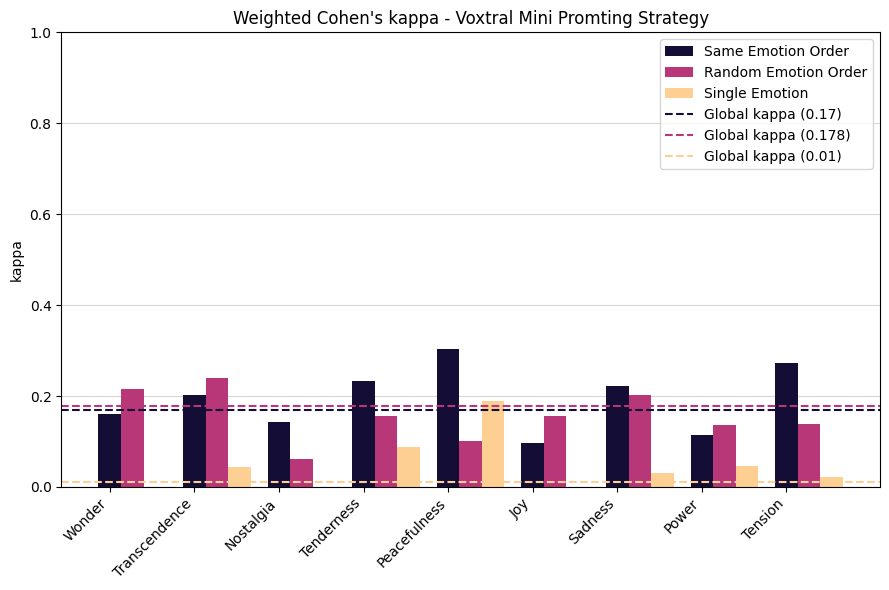

In [52]:
mf_metrics = [voxtral_base_metrics, voxtral_random_metrics, voxtral_single_emo_metrics]
mf_legends = ['Same Emotion Order', 'Random Emotion Order', 'Single Emotion']
emo_bar_chart('kappa',mf_metrics, mf_legends, title = 'Weighted Cohen\'s kappa - Voxtral Mini Promting Strategy', max_tick=1)

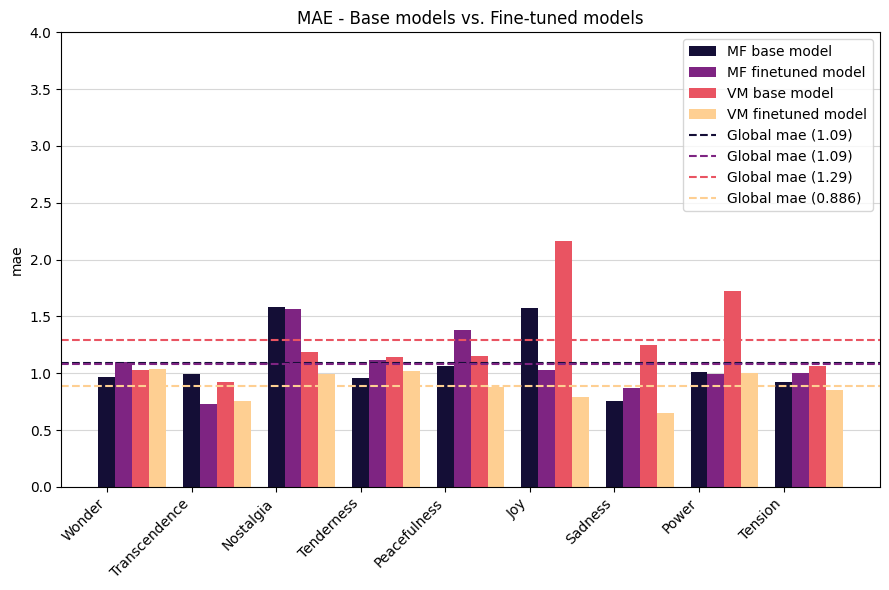

In [53]:
metrics = [mf_base_metrics,  mf_finetuned_metrics, voxtral_base_metrics,voxtral_finetuned_metrics]
legends = ['MF base model', 'MF finetuned model','VM base model',  'VM finetuned model']
emo_bar_chart('mae', metrics, legends, title='MAE - Base models vs. Fine-tuned models', max_tick=4)

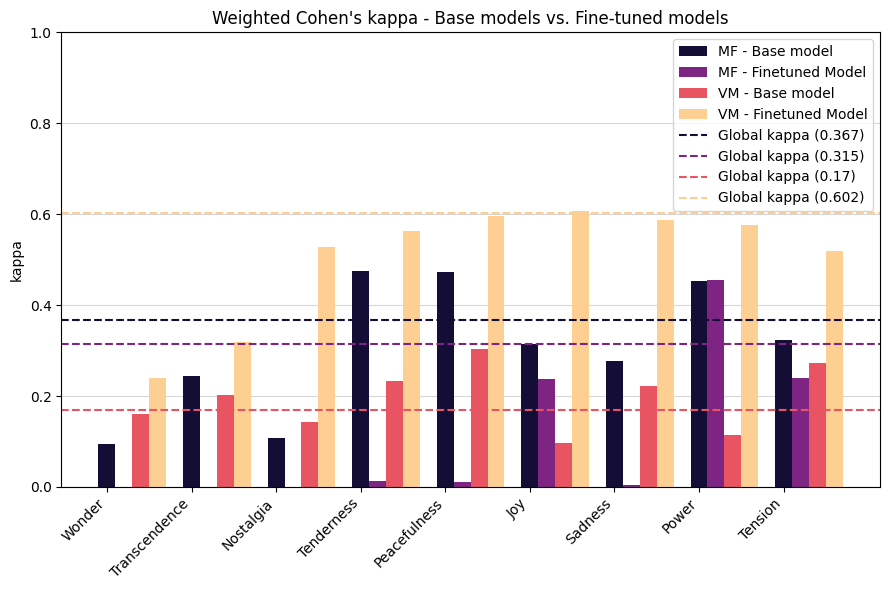

In [54]:
metrics = [mf_base_metrics, mf_finetuned_metrics, voxtral_base_metrics, voxtral_finetuned_metrics]
legends = ['MF - Base model', 'MF - Finetuned Model', 'VM - Base model', 'VM - Finetuned Model']
emo_bar_chart('kappa',metrics, legends, title = 'Weighted Cohen\'s kappa - Base models vs. Fine-tuned models', max_tick=1)

# Confusion Matrix

In [ ]:
def  conf_matrix_plot (model_pred, test_data = test_recoded_df, ylabel='True Scores', normalization = None):

    fig, axs = plt.subplots(3, 3, figsize=(15, 15))
    axs = axs.flatten()

    for i, emo in enumerate(emotions_col):

        # Mask the missing values
        mask = model_pred[emo].notna()
        actual = test_data.loc[mask, emo]
        predicted = model_pred.loc[mask, emo]

        scores = [1,2,3,4,5]

        # Custom portion of the magma colormap
        colors_magma = colors.LinearSegmentedColormap.from_list(
            'truncated_magma_r',
            plt.get_cmap('magma_r')(np.linspace(0.1,0.9,50))
            )

        # Compute confusion matrix
        cm = confusion_matrix(actual,predicted, normalize=normalization)

        # Display the matrix 
        axs[i].matshow(cm, interpolation='nearest', cmap=colors_magma)
        axs[i].set(xticks=np.arange(cm.shape[1]),
                   yticks=np.arange(cm.shape[0]),
                   xticklabels=scores, 
                   yticklabels=scores,
                   title=emo,
                   ylabel=ylabel,
                   xlabel='Predicted Scores')
        
        # Add the values inside each cell with readable text color
        thresh = cm.max() / 2
        for row in range(cm.shape[0]):
            for col in range(cm.shape[1]):
                axs[i].text(col, row, f"{round(cm[row, col],2) if normalization != None else cm[row, col]}",
                            ha='center', va='center',
                            color='white' if cm[row, col] > thresh else 'black',
                            fontsize=12)
    
    fig.tight_layout()
    fig.show()


C:\Users\paulz\AppData\Local\Temp\ipykernel_10536\2498892880.py:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


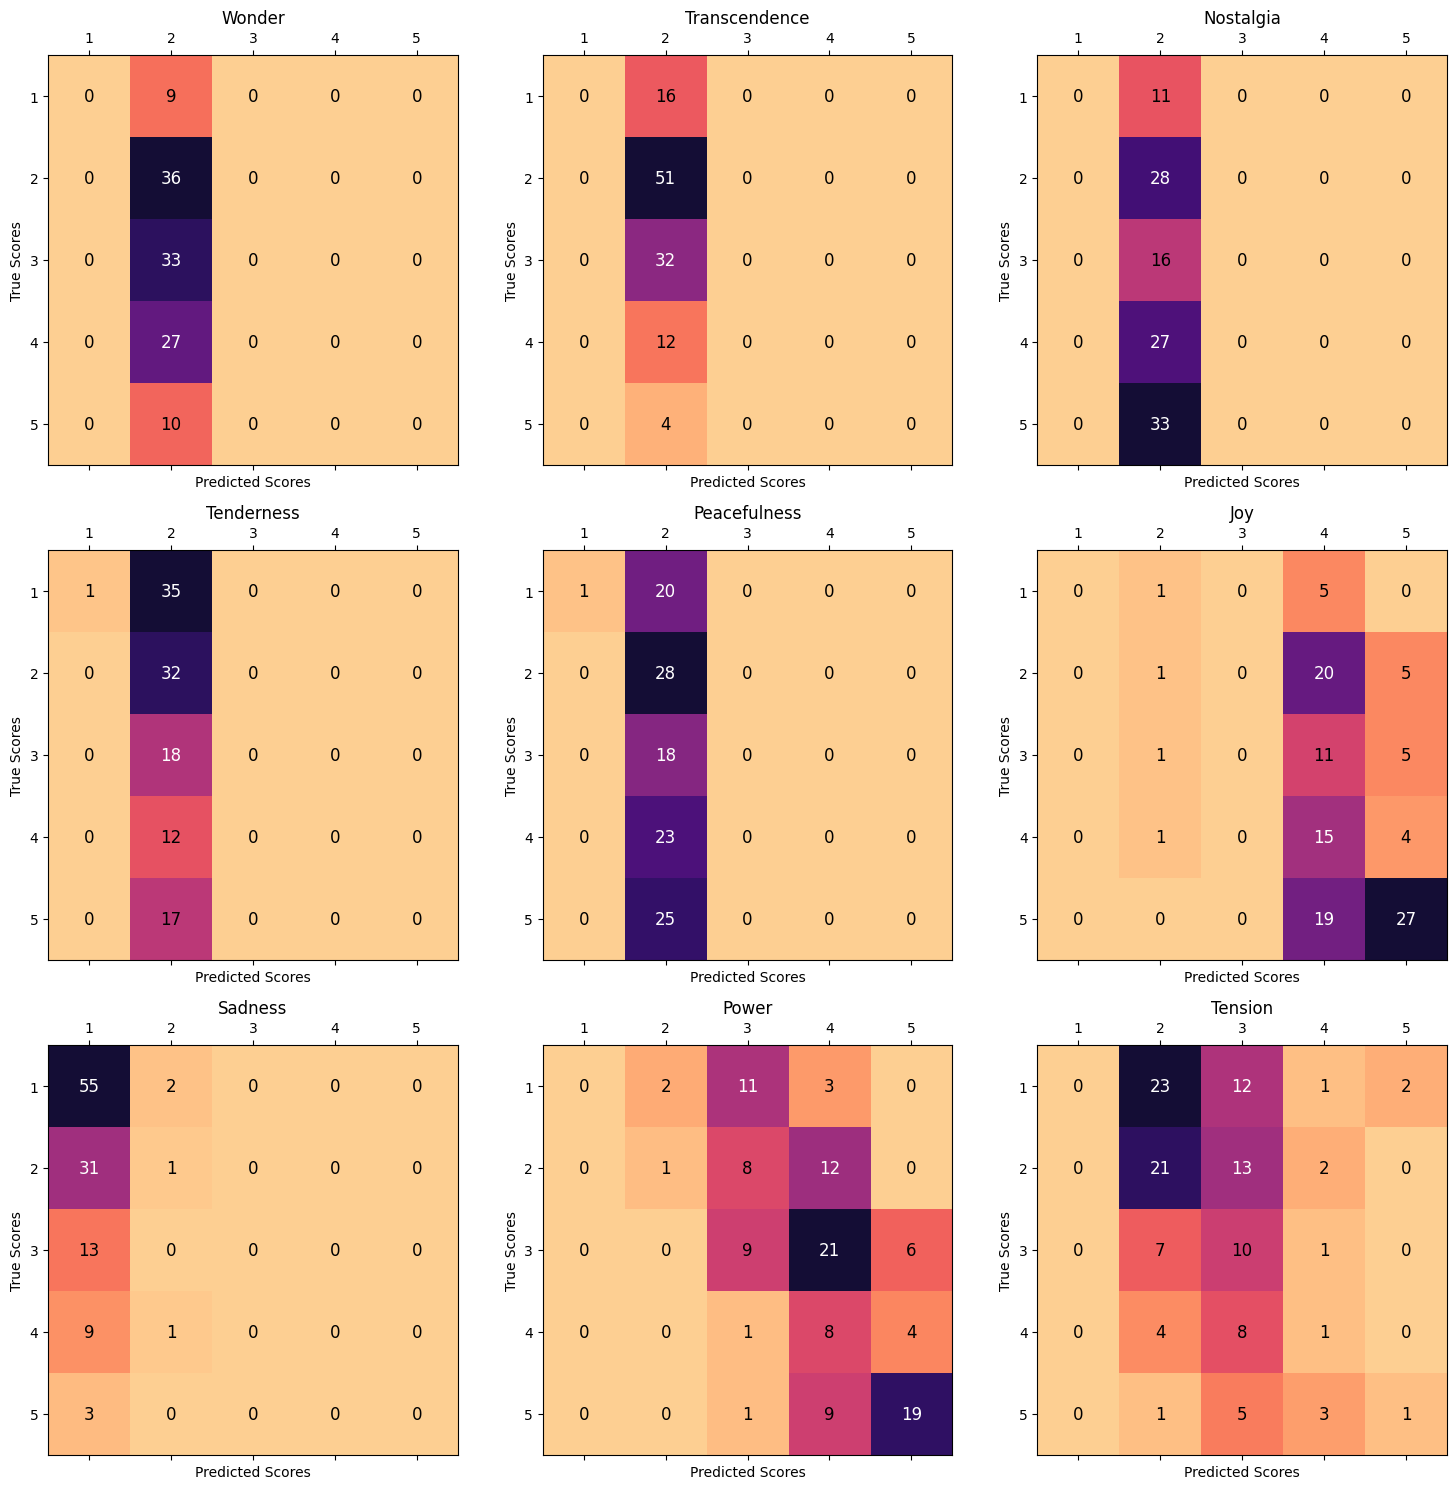

In [34]:
conf_matrix_plot(MF_finetuned_df, normalization=None)

### Loss chart

In [35]:
mf_train_loss = [0.2926,0.0412,0.0404,0.0397,0.0391,0.0385,0.0375]
mf_val_loss = [0.0422,0.0404,0.0401,0.0396,0.0401,0.0401,0.0406]
vm_train_loss = [0.2002, 0.1767, 0.1654, 0.1571, 0.1474, 0.1365, 0.1243]
vm_val_loss = [0.1865 ,0.1718 ,0.1778 ,0.1701 ,0.1789 ,0.1885 ,0.1868]

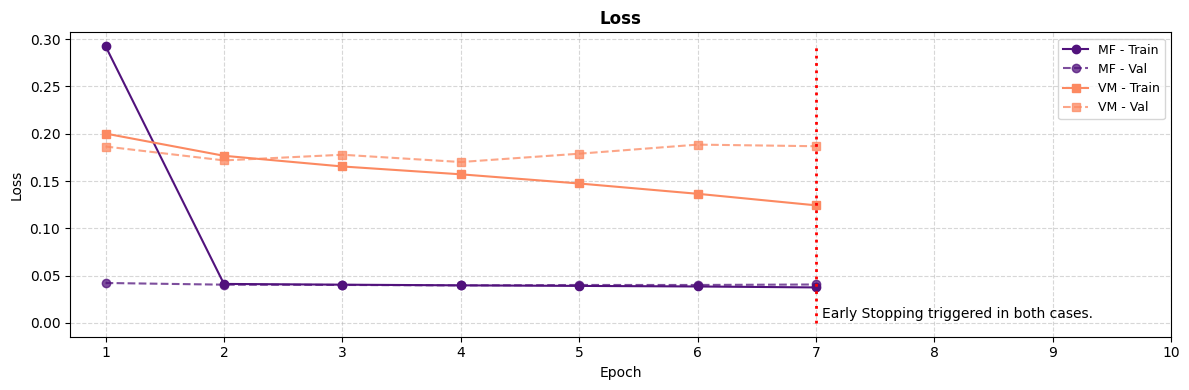

In [ ]:
# Loss plot
fig, ax = plt.subplots(figsize=(12, 4))

# MF train/valid loss
ax.plot(range(1,len(mf_train_loss)+1),  mf_train_loss,  marker="o", lw=1.5, label="MF - Train",  color=plt.cm.magma(.25))
ax.plot(range(1,len(mf_val_loss)+1),  mf_val_loss, marker="o", lw=1.5, ls="--", label="MF - Val", color=plt.cm.magma(.25), alpha=0.75)
# VM train/valid loss
ax.plot(range(1,len(vm_train_loss)+1), vm_train_loss, marker="s", lw=1.5, label="VM - Train", color=plt.cm.magma(.75))
ax.plot(range(1,len(vm_val_loss)+1), vm_val_loss,marker="s", lw=1.5, ls="--", label="VM - Val", color=plt.cm.magma(.75), alpha=0.75)
# Early stopping
plt.vlines(x=7, ymin=0, ymax=max(mf_train_loss), colors='red', ls=':', lw=2)

ax.annotate('Early Stopping triggered in both cases.', xy=(7, 0.05), xytext=(7.05, 0.005))

ax.set_title("Loss", fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_xticks(np.linspace(1,10,10))
ax.legend(fontsize=9); ax.grid(True, ls="--", alpha=0.5)

fig.tight_layout()
plt.show()

## MJF Data Analysis

In [ ]:
# Load annotations and VM predictions
mjf_df = pd.read_csv('../results/mjf_tracks_annoted.csv',
                     delimiter=';',
                     encoding='cp1252',
                     na_values='NA')
mjf_vm_df = pd.read_csv('../results/voxtral_mjf_results.csv',
                     delimiter=',',
                     encoding='utf-8',
                     na_values='NA')

Genre
Jazz       19
Rock       10
Pop        10
Soul        6
Hip Hop     6
Blues       4
Other       5
Name: count, dtype: int64


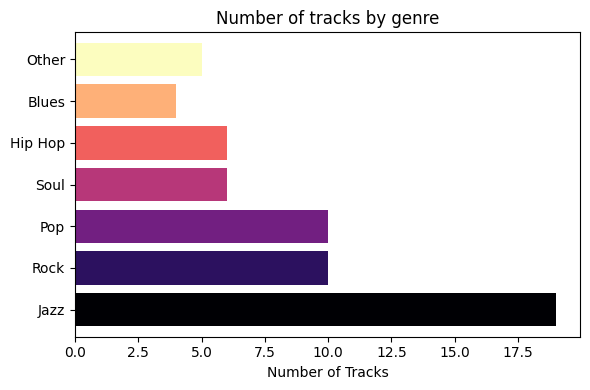

In [ ]:
# Count genre occurences
counts = mjf_df["Genre"].value_counts().sort_values(ascending=False)

# Concat genre with less than 4 occurences
mask = counts < 4
other = counts[mask].sum()
counts = counts[~mask]
counts['Other'] = other 
print(counts)

# Pot genre
colors_magma = plt.cm.magma(np.linspace(0, 1, len(counts)))

plt.figure(figsize=(6, 4))
counts.plot(kind="barh", 
            width=0.8,
            color=colors_magma)
plt.title("Number of tracks by genre")
plt.xlabel("Number of Tracks") 
plt.ylabel("")
plt.tight_layout()
plt.show()

C:\Users\paulz\AppData\Local\Temp\ipykernel_10536\158887136.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


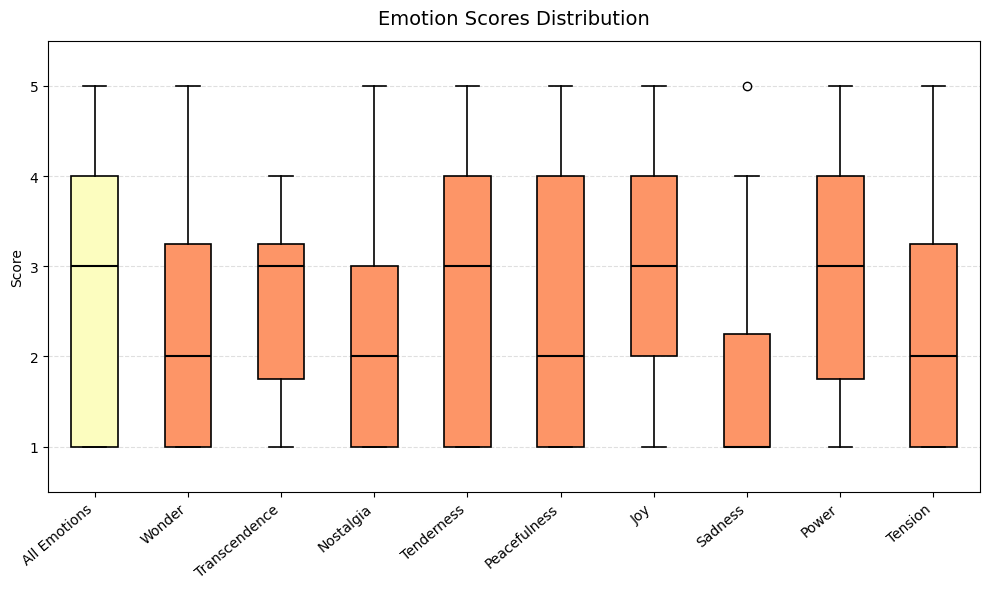

In [ ]:
# Boxplot of the annotaions
scores = mjf_df[emotions_col].to_numpy().ravel()

emotion_data = [mjf_df[emo].dropna().values for emo in emotions_col]

data = [scores] + emotion_data
labels = ['All Emotions'] + emotions_col

fig, ax = plt.subplots(figsize=(10, 6))

box = ax.boxplot(
    data,
    labels=labels,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=1.5),
    boxprops=dict(linewidth=1.2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2)
)

# Soft color palette (highlight "All")
colors = ['#FCFDBFFF'] + ['#FD9567FF'] * len(emotions_col)
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# Styling
ax.set_title("Emotion Scores Distribution", fontsize=14, pad=12)
ax.set_ylabel("Score")
ax.set_ylim(0.5, 5.5)
ax.set_yticks(range(1, 6))
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

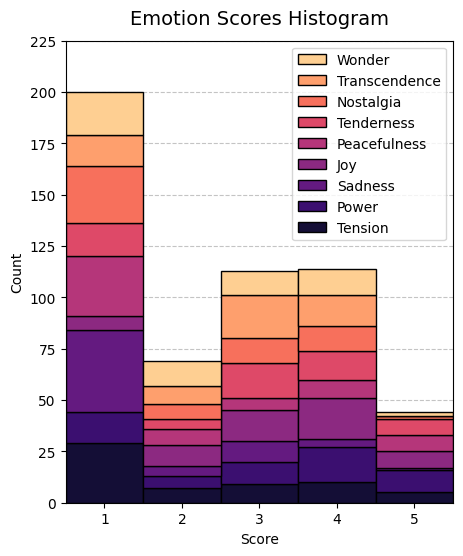

In [ ]:
# Histogramm of the annotations
fig, ax = plt.subplots(figsize=(5, 6))

sns.histplot(mjf_df[emotions_col],
            stat='count',
            palette='magma_r',
            multiple = 'stack',
            fill=True,
            discrete=True,
            alpha = 1
            )

ax.set_title("Emotion Scores Histogram", fontsize=14, pad=12)
ax.set_xlabel("Score")
ax.set_xlim(0.5, 5.5)
ax.set_xticks(range(1, 6, 1))
ax.set_yticks(range(0, 250, 25))
ax.grid(which='both',axis='y', linestyle='--', alpha=.75)
ax.set_axisbelow(True)

plt.show

In [ ]:
# errors between annotations and predictions
mjf_metrics = compute_metrics(model_pred=mjf_vm_df, test_data=mjf_df)
mjf_metrics

({'mae': [1.75, 0.967, 1.5, 1.417, 1.4, 1.6, 0.8, 1.467, 1.483],
  'nmae': [0.438, 0.242, 0.375, 0.354, 0.35, 0.4, 0.2, 0.367, 0.371],
  'nrmse': [0.523, 0.323, 0.461, 0.464, 0.452, 0.516, 0.339, 0.485, 0.471],
  'kappa': [-0.017, 0.081, 0.234, 0.225, 0.246, -0.041, 0.009, 0.22, -0.014],
  'missing values': [0, 0, 0, 0, 0, 0, 0, 0, 0]},
 {'mae': 1.376, 'nmae': 0.344, 'nrmse': 0.453, 'kappa': 0.237})

C:\Users\paulz\AppData\Local\Temp\ipykernel_10536\2498892880.py:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


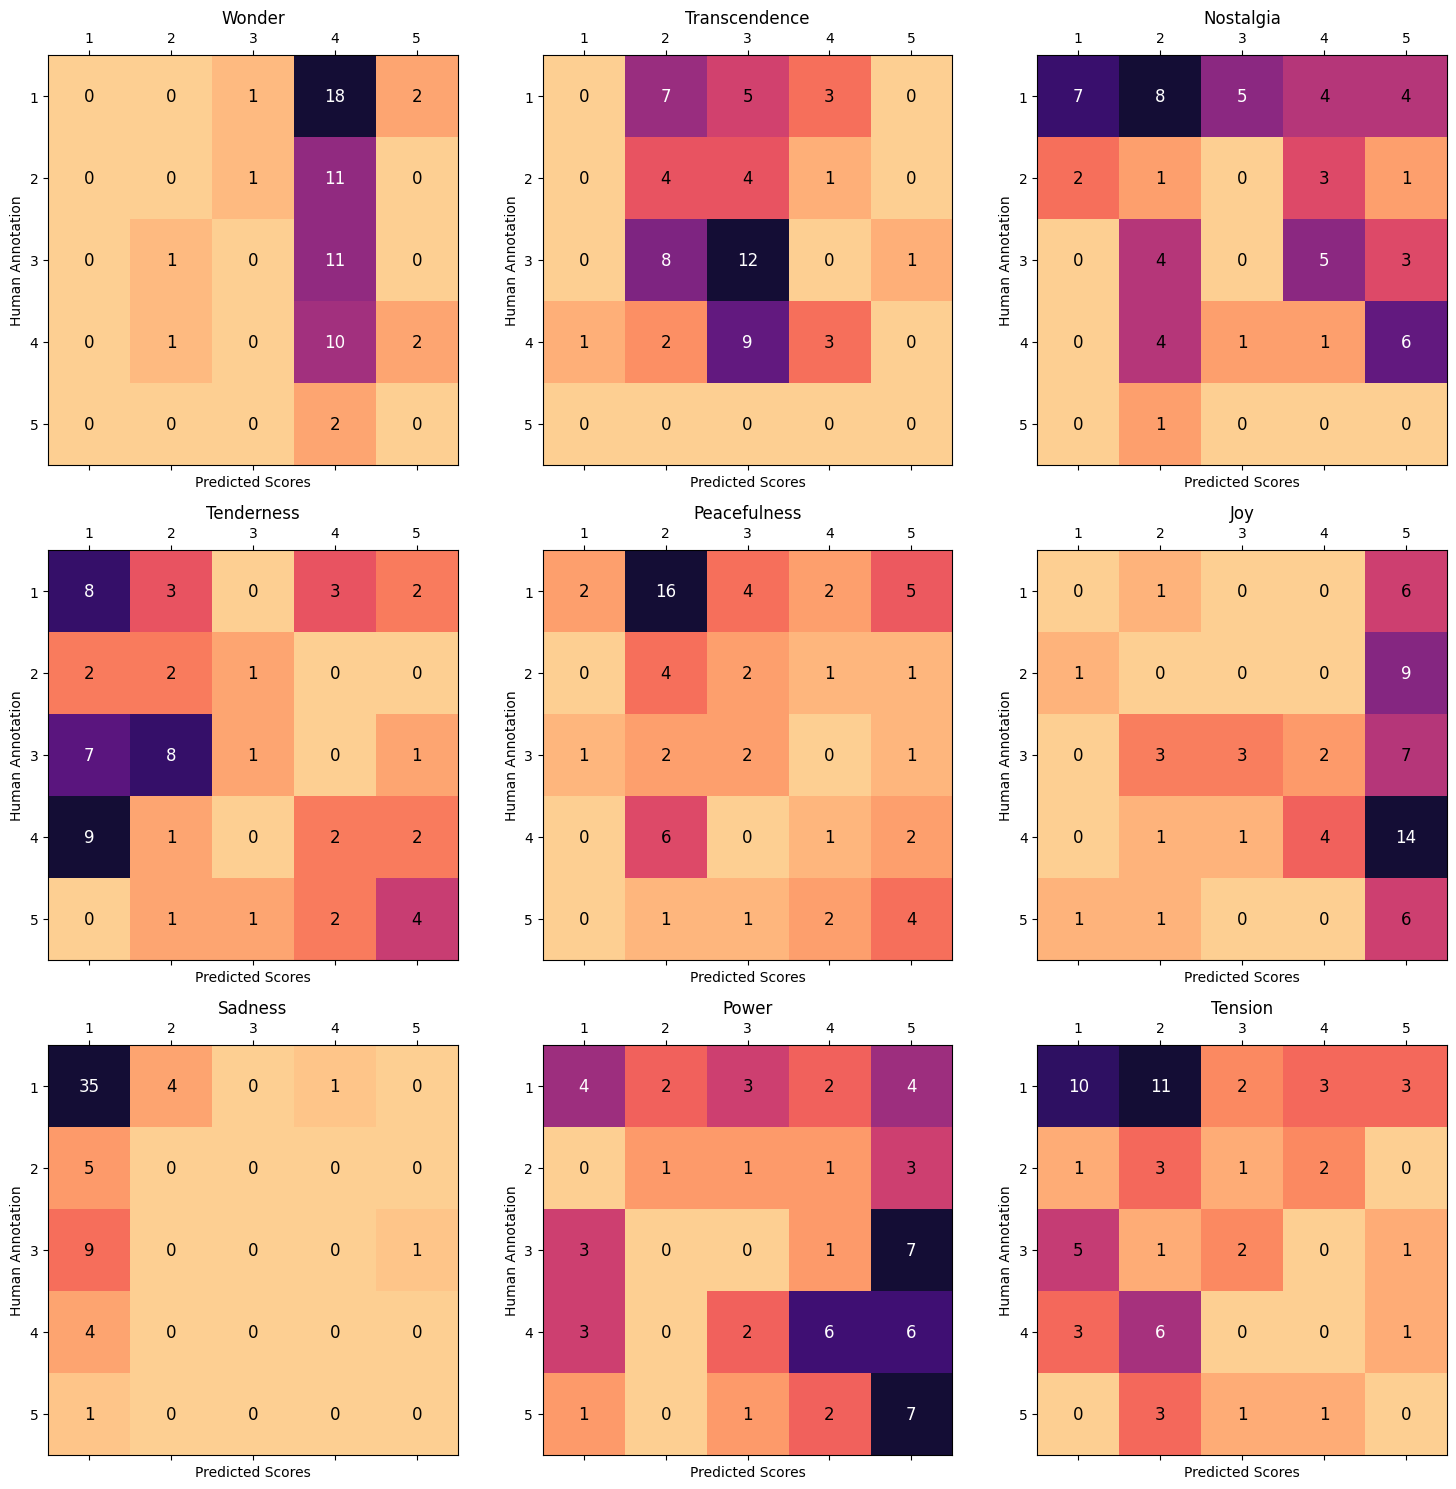

In [ ]:
# Conf. matrix between annotations and predictions
conf_matrix_plot(mjf_vm_df, mjf_df, ylabel='Human Annotation')

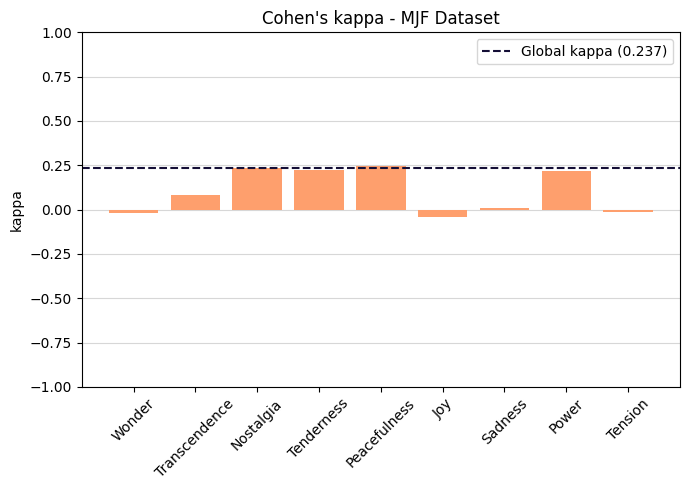

In [ ]:
# Plot Cohen's kappa for each emotion
values =  mjf_metrics[0]['kappa']
labels = emotions_col

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(labels, 
        values, 
        color=plt.cm.magma(np.linspace(.8, 1, 1)))

ax.axhline(y = mjf_metrics[1]['kappa'],
           color=plt.cm.magma(np.linspace(0.1, 1, 1)),
           linestyle='--',
           label= f'{'Global'} kappa ({mjf_metrics[1]['kappa']:.3})')

plt.title('Cohen\'s kappa - MJF Dataset')
plt.ylabel('kappa')
plt.xticks(rotation=45)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=labels)
ax.set_ylim(-1, 1)
ax.grid(which='both',axis='y', linestyle='-', alpha=.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()